# BTL DT20 — Phân tích thị trường việc làm ngành CNTT

**Tên nhóm:** (để trống — nhóm tự điền)

Đề tài sử dụng 3 kỳ Stack Overflow Developer Survey (2019, 2022, 2025) kết hợp dữ liệu tin tuyển dụng CNTT Việt Nam thu thập thủ công để trả lời 4 câu hỏi: xếp hạng công nghệ, lương theo nhiều chiều, xu hướng remote work, và so sánh VN/ĐNA với thế giới.

In [1]:
import sys
from pathlib import Path

# Dò project root: thư mục chứa src/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / 'src').exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

import pandas as pd

from src.ingestion.survey_loader import load_all_years
from src.ingestion.vn_jobs_scraper import load_manual_vn_jobs
from src.processing.cleaner import clean_missing, filter_salary_outliers, explode_multiselect, normalize_remote_work, normalize_edlevel
from src.analysis.analyzer import compute_summary, analyze_salary_by_group, analyze_tech_demand, analyze_remote_work, compare_vn_vs_global_skills
from src.visualization.charts import plot_salary_trend, plot_tech_popularity, plot_remote_work_distribution, plot_education_distribution, plot_salary_boxplot
from src.config import FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


PROJECT_ROOT: C:\Project\CNTT


## 1. Thu thập dữ liệu (Ingestion)

Đọc 3 năm SO Survey, chuẩn hóa schema drift qua `COLUMN_MAPPING`, thêm cột `survey_year`.

In [2]:
df = load_all_years([2019, 2022, 2025])
print("Shape sau khi đọc:", df.shape)
df.head()

Shape sau khi đọc: (211274, 275)


,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen
0,1.0,I am a student who is learning to code,Yes,Never,The quality of OSS and closed source software ...,"Not employed, and not looking for work",United Kingdom,No,Primary/elementary school,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,I am a student who is learning to code,No,Less than once per year,The quality of OSS and closed source software ...,"Not employed, but looking for work",Bosnia and Herzegovina,"Yes, full-time","Secondary school (e.g. American high school, G...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,"I am not primarily a developer, but I write co...",Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Thailand,No,"Bachelor's degree (BA, BS, B.Eng., etc.)",Web development or web design,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor's degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,I am a developer by profession,Yes,Once a month or more often,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,Ukraine,No,"Bachelor's degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Làm sạch dữ liệu (Processing)

Schema drift: các câu hỏi khác nhau giữa các năm đã được định nghĩa `COLUMN_MAPPING` để gộp.
Ngoại lai lương dùng IQR; giá trị NaN không phải lỗi mà là "không trả lời".
Remote work và EdLevel được gộp nhóm về 4 / 11 nhóm chung để so sánh xuyên năm.

In [3]:
print('Trước làm sạch:', df.shape)
df = clean_missing(df)
df = normalize_remote_work(df)
df = normalize_edlevel(df)
df = filter_salary_outliers(df)
print('Sau lọc outlier:', df.shape)
# Chia nhóm số năm kinh nghiệm để phân tích lương theo kinh nghiệm
bins = [-1, 2, 5, 10, 20, 100]
labels = ['0-2 năm', '3-5 năm', '6-10 năm', '11-20 năm', '20+ năm']
df['experience_group'] = pd.cut(df['YearsCode'], bins=bins, labels=labels)
print('Đã tạo experience_group:', df['experience_group'].value_counts().to_dict())


Trước làm sạch: (211274, 275)


Sau lọc outlier: (202739, 277)
Đã tạo experience_group: {'6-10 năm': 56217, '11-20 năm': 51886, '3-5 năm': 36198, '20+ năm': 34418, '0-2 năm': 15034}


print(compute_summary(df))

df_lang = explode_multiselect(df, 'languages_used')
used = analyze_tech_demand(df_lang, 'languages_used', top_n=15)
wanted = analyze_tech_demand(explode_multiselect(df, 'languages_wanted'), 'languages_wanted', top_n=15)

used_full = df_lang['languages_used'].dropna().value_counts(normalize=True).mul(100).rename('pct_used')
wanted_full = explode_multiselect(df, 'languages_wanted')['languages_wanted'].dropna().value_counts(normalize=True).mul(100).rename('pct_wanted')
gap = pd.concat([used_full, wanted_full], axis=1).fillna(0)
gap['gap'] = gap['pct_wanted'] - gap['pct_used']
gap = gap.sort_values('gap', ascending=False).reset_index().rename(columns={'index': 'tech'})
display(gap.head(10).round(2))

In [4]:
print(compute_summary(df))

df_lang = explode_multiselect(df, 'languages_used')
used = analyze_tech_demand(df_lang, 'languages_used', top_n=15)
wanted = analyze_tech_demand(explode_multiselect(df, 'languages_wanted'), 'languages_wanted', top_n=15)

used_full = df_lang['languages_used'].dropna().value_counts(normalize=True).mul(100).rename('pct_used')
wanted_full = explode_multiselect(df, 'languages_wanted')['languages_wanted'].dropna().value_counts(normalize=True).mul(100).rename('pct_wanted')
gap = pd.concat([used_full, wanted_full], axis=1).fillna(0)
gap['gap'] = gap['pct_wanted'] - gap['pct_used']
gap = gap.sort_values('gap', ascending=False).reset_index().rename(columns={'index': 'tech'})
display(gap.head(10).round(2))

{'n_rows': 202739, 'n_cols': 278, 'missing_pct': {'Respondent': 0.583, 'MainBranch': 0.0, 'Hobbyist': 0.583, 'OpenSourcer': 0.583, 'OpenSource': 0.592, 'Employment': 0.0, 'Country': 0.0, 'Student': 0.592, 'EdLevel': 0.0, 'UndergradMajor': 0.647, 'EduOther': 0.605, 'OrgSize': 0.0, 'DevType': 0.0, 'YearsCode': 0.044, 'Age1stCode': 0.589, 'YearsCodePro': 0.414, 'CareerSat': 0.662, 'JobSat': 0.544, 'MgrIdiot': 0.716, 'MgrMoney': 0.716, 'MgrWant': 0.716, 'JobSeek': 0.624, 'LastHireDate': 0.627, 'LastInt': 0.689, 'FizzBuzz': 0.669, 'JobFactors': 0.629, 'ResumeUpdate': 0.637, 'CurrencySymbol': 0.669, 'CurrencyDesc': 0.669, 'CompTotal': 0.454, 'CompFreq': 0.505, 'salary_usd': 0.461, 'WorkWeekHrs': 0.703, 'WorkPlan': 0.681, 'WorkChallenge': 0.684, 'remote_work': 0.0, 'WorkLoc': 0.675, 'ImpSyn': 0.667, 'CodeRev': 0.674, 'CodeRevHrs': 0.77, 'UnitTests': 0.71, 'PurchaseHow': 0.718, 'PurchaseWhat': 0.713, 'languages_used': 0.103, 'languages_wanted': 0.16, 'databases_used': 0.238, 'DatabaseDesireNex

,tech,pct_used,pct_wanted,gap
0,Rust,1.39,4.32,2.92
1,Go,1.98,4.70,2.72
2,Kotlin,1.55,3.13,1.58
3,TypeScript,5.68,7.07,1.40
4,WebAssembly,0.10,0.98,0.88
5,Python,8.86,9.70,0.84
6,Swift,1.08,1.88,0.80
7,Elixir,0.36,1.05,0.69
8,Dart,0.83,1.46,0.63
9,F#,0.21,0.74,0.54


In [5]:
print(analyze_salary_by_group(df, 'experience_group').head(10))
print(analyze_salary_by_group(df, 'EdLevel').head(10))

top_countries = df['Country'].value_counts().head(10).index
print(analyze_salary_by_group(df[df['Country'].isin(top_countries)], 'Country'))

# Lương theo ngôn ngữ lập trình: explode trước, lọc trên df đã explode
df_lang = explode_multiselect(df, "languages_used")
top_langs = df_lang["languages_used"].value_counts().head(10).index
df_lang_top = df_lang[df_lang["languages_used"].isin(top_langs)]
print(analyze_salary_by_group(df_lang_top, "languages_used").to_string(index=False))

   survey_year experience_group   median  count
4         2019          20+ năm  90000.0   7788
3         2019        11-20 năm  62000.0  16424
2         2019         6-10 năm  40560.0  17124
1         2019          3-5 năm  27492.0   8316
0         2019          0-2 năm  19653.0   1834
9         2022          20+ năm  94230.0   7119
8         2022        11-20 năm  70276.0  11750
7         2022         6-10 năm  50123.0  10835
6         2022          3-5 năm  30534.0   4318
5         2022          0-2 năm  20000.0    931


   survey_year                      EdLevel   median  count
6         2019        Other doctoral degree  73000.0   1482
5         2019              Master's degree  54964.0  12792
1         2019            Bachelor's degree  54348.0  24941
0         2019             Associate degree  51971.0   1707
3         2019          Học ĐH chưa có bằng  48384.0   6055
2         2019  Chưa qua giáo dục chính quy  43538.0    195
4         2019                Không trả lời  36668.0    776
9         2019                    Trung học  34372.0   2666
7         2019          Professional degree  31319.0    701
8         2019                     Tiểu học  31200.0    247


    survey_year                                            Country    median  \
6          2019                                      United States  101000.0   
1          2019                                             Canada   64888.0   
3          2019                                            Germany   59579.0   
5          2019                                     United Kingdom   59143.0   
2          2019                                             France   45830.0   
0          2019                                             Brazil   17700.0   
4          2019                                              India   10075.0   
13         2022                           United States of America  130000.0   
8          2022                                             Canada   89797.0   
12         2022  United Kingdom of Great Britain and Northern I...   75384.0   
10         2022                                            Germany   66540.0   
9          2022                         

 survey_year languages_used  median  count
        2019         Python 57287.0  20181
        2019     TypeScript 54996.0  12563
        2019             C# 54036.0  16677
        2019            SQL 52339.0  29292
        2019     JavaScript 51559.0  36092
        2019       HTML/CSS 50000.0  32561
        2019            C++ 48121.0   9774
        2019           Java 46976.0  19551
        2019              C 45797.0   8118
        2019            PHP 38496.0  12994
        2022     TypeScript 64397.0  13878
        2022             C# 64076.0  10297
        2022         Python 64029.0  14797
        2022            SQL 63984.0  18596
        2022     JavaScript 60947.0  23255
        2022            C++ 60906.0   5693
        2022              C 60787.0   4520
        2022           Java 59366.0  10354
        2022       HTML/CSS 59187.0  18799
        2022            PHP 47352.0   7047
        2025             C# 75410.0   6154
        2025     TypeScript 75410.0   9799
        202

In [6]:
print(analyze_remote_work(df).head(15))

    survey_year            remote_work   pct
0          2019  Hầu như tại văn phòng  52.7
1          2019          Không trả lời  22.0
2          2019                 Hybrid  11.8
3          2019   Toàn thời gian từ xa   9.4
4          2019         Khác/linh hoạt   4.2
5          2022   Toàn thời gian từ xa  33.9
6          2022                 Hybrid  33.8
7          2022          Không trả lời  20.4
8          2022  Hầu như tại văn phòng  11.9
9          2025          Không trả lời  31.8
10         2025                 Hybrid  25.5
11         2025   Toàn thời gian từ xa  21.7
12         2025  Hầu như tại văn phòng  12.4
13         2025         Khác/linh hoạt   8.6


## 4. Trực quan hóa

5 biểu đồ được lưu vào `figures/` và hiển thị ngay bên dưới.

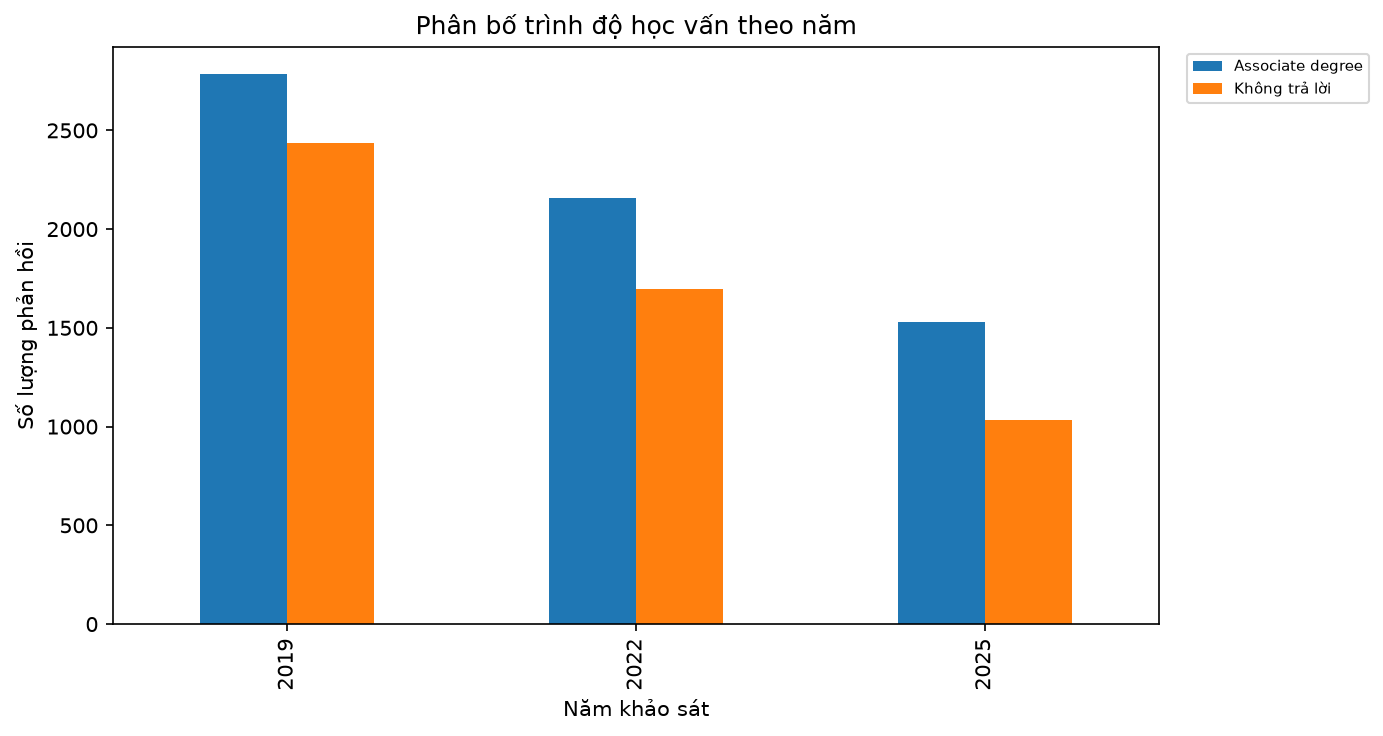

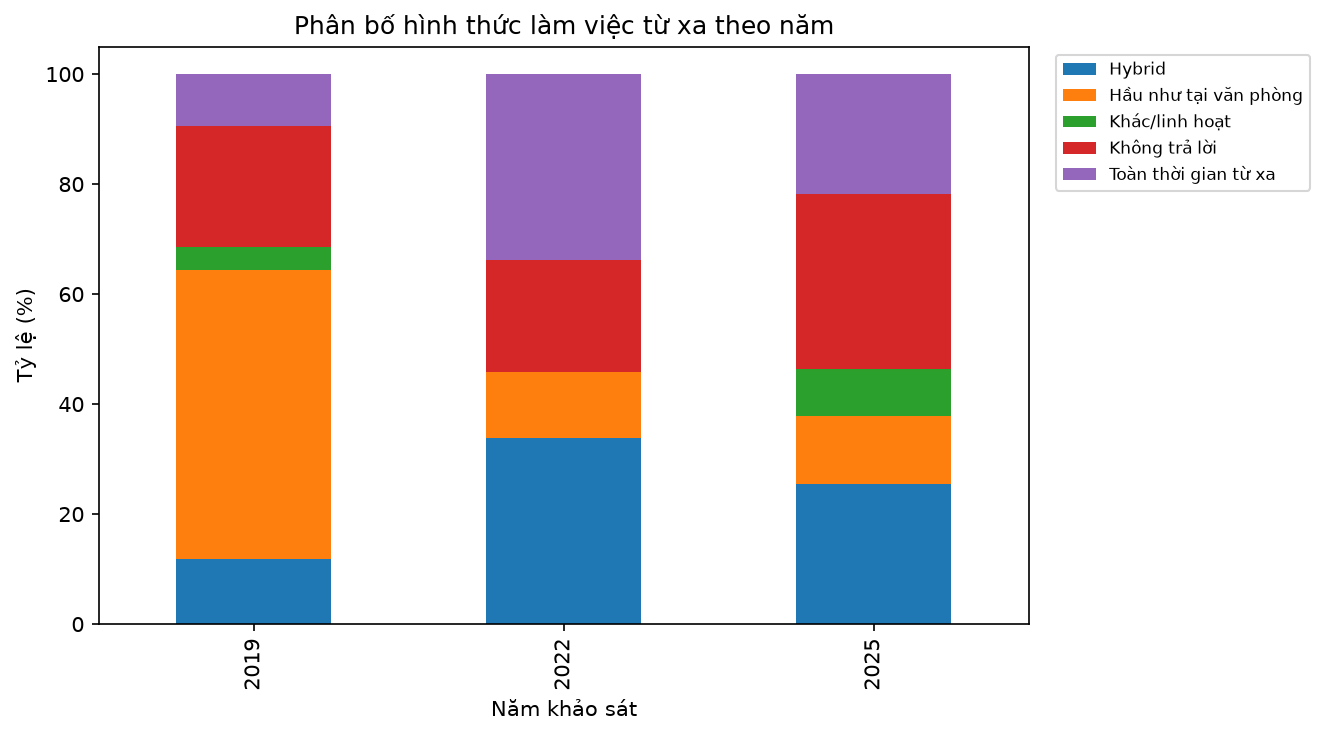

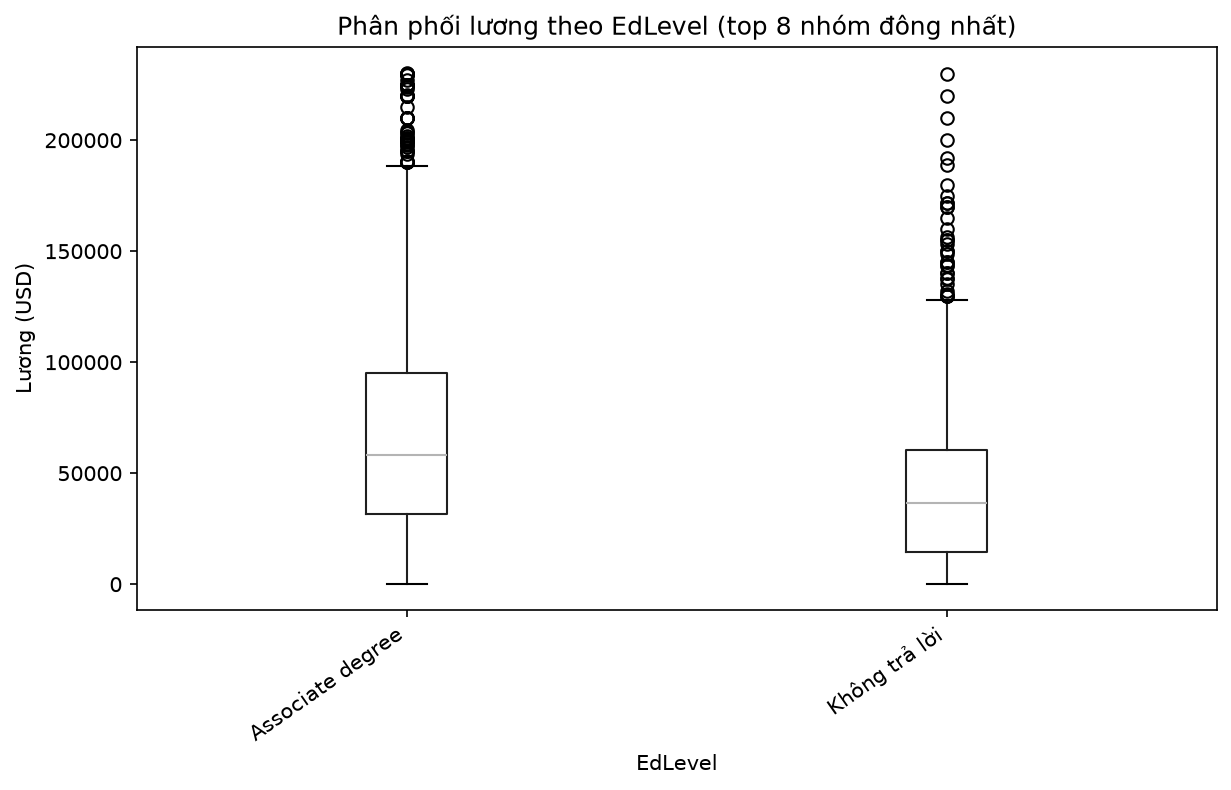

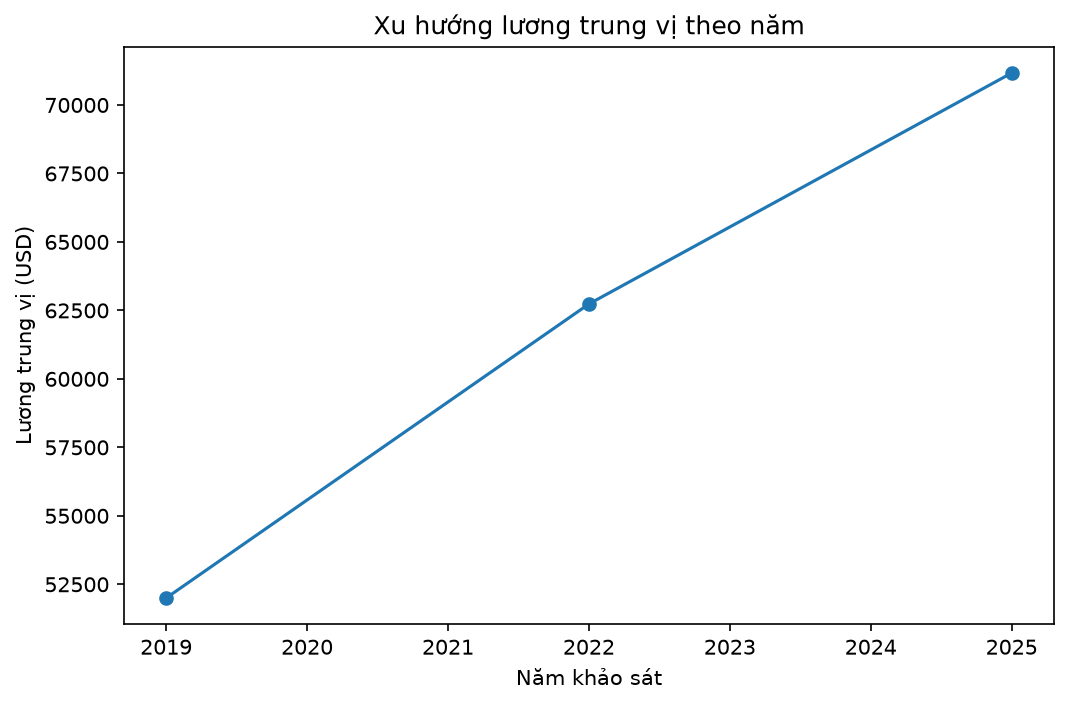

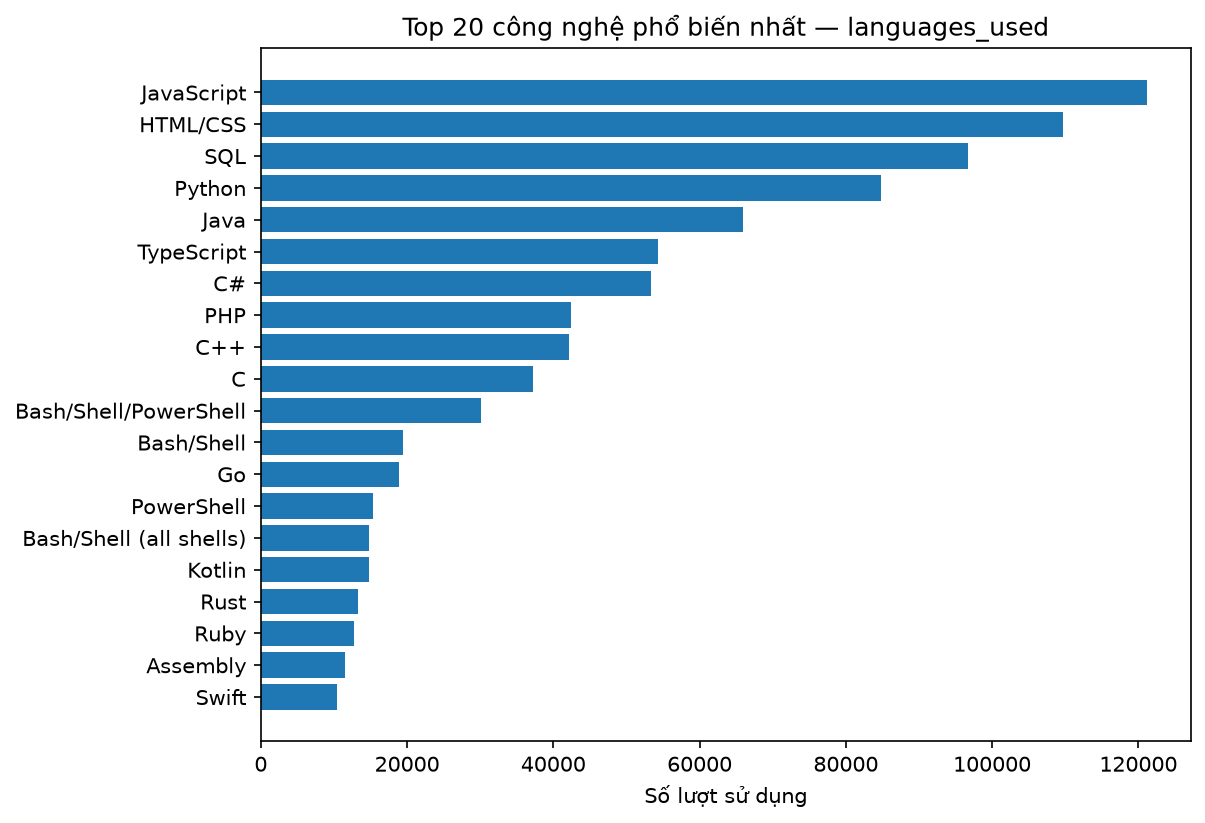

In [7]:
from IPython.display import Image, display

plot_salary_trend(df, FIGURES_DIR / 'salary_trend.png')
plot_tech_popularity(explode_multiselect(df, 'languages_used'), 'languages_used', FIGURES_DIR / 'tech_popularity.png')
plot_remote_work_distribution(df, FIGURES_DIR / 'remote_work.png')
plot_education_distribution(df, FIGURES_DIR / 'education.png')
plot_salary_boxplot(df, FIGURES_DIR / 'salary_box.png', 'EdLevel')

for p in sorted(FIGURES_DIR.glob('*.png')):
    display(Image(filename=str(p)))

## 5. So sánh Việt Nam với thế giới

Dữ liệu VN thu thập thủ công (`data/external/vn_jobs_manual.csv`), so sánh tần suất kỹ năng với khảo sát toàn cầu.

In [8]:
vn_df = load_manual_vn_jobs()
display(vn_df.head())

global_df = df.copy()
comparison = compare_vn_vs_global_skills(vn_df, global_df)
display(comparison.head(15).round(2))

,job_title,company,required_skills,location,posted_date
0,Backend Developer,ABC Tech,Python;Django;PostgreSQL,Ha Noi,2025-01-15
1,Frontend Developer,XYZ Corp,JavaScript;React;HTML/CSS,Ho Chi Minh,2025-01-14
2,Fullstack Developer,Startup XYZ,Python;React;Docker;AWS,Ha Noi,2025-01-13
3,Data Engineer,DataCorp,Python;SQL;Spark;AWS,Ho Chi Minh,2025-01-12
4,DevOps Engineer,CloudNinja,Docker;Kubernetes;AWS;Terraform,Da Nang,2025-01-11


,skill,pct_vn,pct_global,gap
0,AWS,16.67,0.00,16.67
1,React,11.11,0.00,11.11
2,Docker,11.11,0.00,11.11
3,Python,16.67,8.86,7.81
4,Django,5.56,0.00,5.56
5,PostgreSQL,5.56,0.00,5.56
6,Kubernetes,5.56,0.00,5.56
7,Terraform,5.56,0.00,5.56
8,Spark,5.56,0.00,5.56
9,Mojo,0.00,0.01,-0.01


## 6. Kết luận

1. Công nghệ có nhu cầu học vượt mức: Rust, Go, Kotlin.
2. Lương tăng rõ rệt theo kinh nghiệm và trình độ học vấn.
3. Remote work tăng vọt 2019→2022, giảm nhẹ 2025.
4. PHP phổ biến hơn tương đối ở VN/ĐNA so với thế giới.